In this notebook, we enter the modeling phase of our predictive maintenance project. We will experiment with different models, perform hyperparameter tuning, and finally evaluate model performance on the NASA test set (`test_FD001.txt` and `RUL_FD001.txt`).

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# Loading Features

In [2]:
# Load the features dataframe saved in notebook 2
df = pd.read_parquet('../data/processed/fd001_features.parquet.parquet')

In [77]:
df.columns

Index(['engine_number', 'time_cycle', 'setting_1', 'setting_2', 'sensor_2',
       'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_2_roll_mean_17',
       'sensor_3_roll_mean_17', 'sensor_4_roll_mean_17',
       'sensor_6_roll_mean_17', 'sensor_7_roll_mean_17',
       'sensor_8_roll_mean_17', 'sensor_9_roll_mean_17',
       'sensor_11_roll_mean_17', 'sensor_12_roll_mean_17',
       'sensor_13_roll_mean_17', 'sensor_14_roll_mean_17',
       'sensor_15_roll_mean_17', 'sensor_17_roll_mean_17',
       'sensor_20_roll_mean_17', 'sensor_21_roll_mean_17',
       'sensor_2_roll_std_10', 'sensor_3_roll_std_10', 'sensor_4_roll_std_10',
       'sensor_6_roll_std_10', 'sensor_7_roll_std_10', 'sensor_8_roll_std_10',
       'sensor_9_roll_std_10', 'sensor_11_roll_std_10',
       'sensor_12_roll_std_10', 'sensor_13_roll_std_10',
       'sensor_14

# Train/Validation Split

We perform an engine-based train/validation split to avoid data leakage. Since each engine represents an independent time series, splitting at row level would leak temporal and engine-specific patterns.

Instead, we split by engine IDs so that all cycles of a given engine are contained in either the training or validation set.

We use a 70/30 split (instead of 80/20) to obtain a slightly larger validation set, which leads to more stable evaluation metrics and a more reliable estimate of generalization across different degradation trajectories.

The exact ratio is not critical; the key principle is strict separation at engine level.

After the split, we remove `engine_number` and `time_cycle` from the feature set, as they are only required for splitting and time-based processing, not for model training.

In [3]:
# Get all engines
engines = df["engine_number"].unique()
engines

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [4]:
# Engine-level split
train_engines, val_engines = train_test_split(
    engines,
    test_size=0.3,
    random_state=42
)

In [5]:
# Filter data by engines
train_df = df[df["engine_number"].isin(train_engines)].copy()
val_df = df[df["engine_number"].isin(val_engines)].copy()

In [6]:
train_df["engine_number"].unique()

array([  2,   3,   4,   6,   7,   8,   9,  12,  14,  15,  17,  18,  20,
        21,  22,  24,  25,  26,  28,  29,  30,  33,  35,  36,  37,  38,
        39,  42,  44,  47,  48,  49,  50,  51,  52,  53,  55,  57,  58,
        59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  72,  75,
        76,  79,  80,  82,  83,  85,  86,  87,  88,  90,  92,  93,  94,
        95,  96,  98,  99, 100])

# Defining X and y

In this step, we separate the dataset into features (X) and the target variable (y). This distinction is required to prepare the data for model training, where X represents the input variables and y corresponds to the Remaining Useful Life (RUL).

Additionally, we remove the `engine_number` column from the feature set, as it is only an identifier and does not contain predictive information.

The `time_cycle` column is initially retained, as it may contain meaningful information about the operating duration of each engine and can serve as a relevant predictor for degradation modeling. Its influence will be evaluated during model training and feature importance analysis. In a second experiment, we will also test a variant where `time_cycle` is removed to assess its impact on model performance.

In [7]:
X_train = train_df.drop(["RUL", "engine_number"], axis=1)

In [8]:
y_train = train_df["RUL"]

In [9]:
X_val = val_df.drop(["RUL", "engine_number"], axis=1)

In [10]:
y_val = val_df["RUL"]

# Baseline Model

We start with a simple baseline model to serve as a reference for comparison. We train a basic linear regression model (without regularization) on the training set and evaluate its performance on the validation set.

We apply a clipping threshold to the target variable (RUL) prior to model training.

- **The problem:** In the early phase of an engine’s lifecycle, the system operates under stable conditions and sensor readings show little to no degradation. However, the Remaining Useful Life (RUL) decreases linearly from the beginning. This creates a mismatch between a changing target and largely stationary input features, which can lead the model to learn noise instead of meaningful degradation patterns.

- **The solution:** To address this, we cap the maximum RUL at a fixed threshold (e.g., 125 cycles). This flattens the target in the early lifecycle phase, ensuring that the model does not attempt to learn artificial degradation signals during periods of healthy operation.

- **The benefit:** This transformation improves learning stability by reducing sensitivity to non-informative early cycles. As a result, the model focuses more strongly on actual degradation-related behavior, leading to more robust and reliable error metrics during training.

- **Validation strategy:** To ensure a fair and consistent evaluation during model selection and hyperparameter tuning, validation performance is strictly measured against the clipped validation target (`y_val_clipped`). This ensures that training and evaluation are aligned in terms of target distribution and avoids misleading error signals in the early-life regime.

- **Production and testing outlook:** Final evaluation for production readiness is performed on the original, unclipped test set (`y_test`). Since the real-world test targets retain the full RUL range (including high values in the early lifecycle phase), a distribution mismatch is introduced in this region. During early cycles, the model will predict the clipped maximum RUL while the true values are higher, which can lead to inflated error metrics such as RMSE. However, this does not necessarily reflect reduced predictive quality in the degradation-critical phase close to failure, which remains the primary objective of the model.

We standardize the features for the baseline model. This is done for several reasons:

1. **More stable coefficients**  
   Standardization makes the intercept more interpretable and ensures that model weights become comparable across features.

2. **Improved numerical stability**  
   This is especially important in the presence of many correlated features, as it helps prevent feature dominance caused by differing value scales.

3. **Better interpretability**  
   After scaling, the importance of features becomes more comparable, allowing a clearer understanding of which variables contribute most to the prediction.

Furthermore, we train the baseline model twice: once including the `time_cycle` feature and once without it. This allows us to evaluate the impact of `time_cycle` on both model performance and learned parameters.

In [91]:
scaler = StandardScaler()

In [92]:
X_train_standardized = scaler.fit_transform(X_train)

In [93]:
X_val_standardized = scaler.transform(X_val)

In [94]:
baseline_model = LinearRegression()

In [95]:
baseline_model.fit(X_train_standardized, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](78,)","[-9.66,-0.28, 0.04,..., 2.27,-0.06, 2.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,90.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,78
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,78
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](78,)","[561. ,303.16,172.08,..., 11.66, 9.92, 5.01]"


In [96]:
joblib.dump(baseline_model, '../models/baseline_model_lin_reg.pkl')

['../models/baseline_model_lin_reg.pkl']

In [97]:
baseline_model = joblib.load('../models/baseline_model_lin_reg.pkl')

In [112]:
# Print the optimal weight (slope) and bias (intercept)
print("Coefficients (Slope):", baseline_model.coef_)
print("Intercept (Bias):", baseline_model.intercept_)

# Predict and score using test data
y_pred = baseline_model.predict(X_val_standardized)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R-squared Score:", r2_score(y_val, y_pred))

Coefficients (Slope): [-9.66399795e+00 -2.78670142e-01  3.70028789e-02  6.07464896e-03
 -4.28393260e-02  6.12049653e-02  2.58206101e-02  1.94187202e-01
  1.92190283e-01  3.17567584e-01 -5.55255134e-01 -4.20088490e-02
  1.59984963e-01  1.18364120e-01  3.94021012e-02 -1.89279868e-01
  4.64056675e-02  7.40660903e-02 -7.66539808e+00 -4.41405341e-02
 -4.99341367e+00  8.09830668e-01  6.91110265e+00  8.44799466e+00
  1.81295832e+01 -9.81236663e+00 -3.75356560e+00  1.29125079e+01
 -1.38438232e+01 -7.13850861e+00 -4.33947733e+00  3.21597372e+00
  4.13139916e+00  3.99567758e-02 -5.84570037e-01  7.48083554e-02
 -3.87265816e-01 -1.42576160e-01 -8.25310590e-01 -1.36010593e+00
  2.33674507e-01 -2.53737385e-01  6.86515992e-01 -2.66472632e-02
 -6.47495485e-01 -3.06144874e-01  1.25684235e-01  7.85014096e-01
  8.62865510e-02 -2.24396972e+00 -1.16121439e-01 -1.36802537e+00
 -6.18548890e-02 -2.88180466e+00  7.73323309e-02 -3.26977164e-01
  2.80364583e-02  2.95080108e+00  2.22787970e-01 -2.95665756e+00
  3

An R² score of approximately 0.80 is achieved, meaning that around 80% of the variance in the Remaining Useful Life (RUL) is explained by the linear regression baseline model.

For the FD001 dataset, which contains noisy and highly dynamic sensor signals, this represents a strong performance for a linear baseline model. It indicates that the engineered feature set already captures substantial predictive structure related to engine degradation.

The root mean squared error of approximately 22 is considered a strong result in this context, given that RUL values span a broad range (from 0 up to 200+ cycles). The metric is sensitive to larger deviations due to the squared error component, which amplifies occasional high prediction errors.

The learned coefficients show varying influence strengths across features. Negative coefficients indicate that increasing feature values are associated with a decrease in predicted RUL, which is consistent with degradation behavior. Positive coefficients indicate the opposite effect.

The wide range of coefficient magnitudes suggests strong feature correlation and redundancy within the engineered feature set, particularly due to rolling statistics and slope-based features. As a result, the linear model distributes weights unevenly across correlated inputs, and individual coefficients should not be interpreted in isolation but only in the context of the full feature space.

The intercept (~90.93) represents the baseline prediction of the model when all standardized features are equal to zero, i.e., when the engine is in an average operating state. In practical terms, this corresponds to an estimated remaining useful life of roughly 91 cycles under typical operating conditions in the dataset.

All evaluation metrics are computed on the clipped target variable (`y_clipped`). This clipped formulation is used consistently across all subsequent model comparisons to ensure a stable and comparable evaluation framework, while still preserving relative performance differences between models.

Overall, this result indicates that the model captures a meaningful and robust relationship between the engineered sensor features and the target variable, despite the inherent noise and complexity of the FD001 dataset.

In the following, we train a second variant of the baseline model without the `time_cycle` feature. We then briefly evaluate its performance and compare it to the original baseline model to assess the impact of `time_cycle` on predictive performance and learned parameters.

In [99]:
X_train_without_time_cycle = X_train.drop("time_cycle", axis=1)
X_val_without_time_cycle = X_val.drop("time_cycle", axis=1)

In [100]:
scaler_2 = StandardScaler()

In [101]:
X_train_without_time_cycle_standardized = scaler_2.fit_transform(X_train_without_time_cycle)

In [102]:
X_val_without_time_cycle_standardized = scaler_2.transform(X_val_without_time_cycle)

In [103]:
baseline_model_without_time_cycle = LinearRegression()

In [104]:
baseline_model_without_time_cycle.fit(X_train_without_time_cycle_standardized, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](77,)","[-0.2 ,-0.19, 0.03,..., 2.41,-0.08, 1.99]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,90.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,77
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,77
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](77,)","[555.24,302.65,172.07,..., 11.66, 9.92, 5.01]"


In [105]:
joblib.dump(baseline_model_without_time_cycle, '../models/baseline_model_without_time_cycle_lin_reg.pkl')

['../models/baseline_model_without_time_cycle_lin_reg.pkl']

In [106]:
baseline_model_without_time_cycle = joblib.load('../models/baseline_model_without_time_cycle_lin_reg.pkl')

In [114]:
# Print the optimal weight (slope) and bias (intercept)
print("Coefficients (Slope):", baseline_model_without_time_cycle.coef_)
print("Intercept (Bias):", baseline_model_without_time_cycle.intercept_)

# Predict and score using test data
y_pred = baseline_model_without_time_cycle.predict(X_val_without_time_cycle_standardized)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R-squared Score:", r2_score(y_val, y_pred))

Coefficients (Slope): [-1.99756762e-01 -1.89964002e-01  3.09638096e-02  4.58904687e-03
  1.68941892e-01  5.42569792e-02  1.81533849e-01  1.86769755e-01
  1.70860247e-01 -5.47117751e-01 -1.20809362e-01  2.17886766e-01
  2.44993656e-01  7.69136400e-02 -2.25227029e-01  3.00538896e-03
  1.01450087e-01 -6.78074099e+00 -1.43974196e+00 -7.95647150e+00
  6.49817816e-01  7.53662113e+00  1.21634141e+01  1.26440190e+01
 -1.12686953e+01 -1.29597765e+00  1.51280595e+01 -1.10867735e+01
 -5.10629293e+00 -5.79971150e+00  5.98796100e+00  5.76309217e+00
 -3.51865526e-01 -6.22043504e-01 -1.22928719e-01 -6.50260285e-01
  7.61275845e-02 -8.84147197e-01 -4.81769863e-01  3.11058077e-01
 -4.84115344e-01  5.14163852e-01  5.89475134e-01 -5.57027324e-01
 -3.67286714e-01  2.41830039e-02  9.01718116e-01  1.22350954e-01
 -2.32766228e+00 -1.50227374e-01 -1.41513026e+00 -5.69808875e-02
 -3.05263738e+00  7.90894497e-02 -4.54085693e-01  1.73232081e-02
  3.13173644e+00  2.38249969e-01 -3.05755340e+00  3.15980542e-02
 -1

We observe that the model without the `time_cycle` feature performs slightly worse, achieving an R² score of approximately 0.77 and a root mean squared error of abou 24.

This indicates that the `time_cycle` feature contributes meaningfully to explaining variance in the target variable, as it encodes explicit temporal degradation information. However, the performance drop compared to the full model remains moderate, suggesting that a large portion of the predictive signal is already captured by the engineered sensor-based features.

The learned coefficients show a similar pattern to the previous model, with both positive and negative values indicating mixed feature contributions. The magnitude distribution again reflects strong correlations among engineered rolling and slope-based features, leading to shared or redistributed importance across related inputs.

Overall, while the removal of `time_cycle` reduces model performance, the linear baseline remains relatively strong, confirming that the feature engineering process already extracts substantial degradation-related structure from the raw sensor data.

# XGBoost Regression Model

After establishing a linear baseline, we now move to a significantly more powerful model architecture: Extreme Gradient Boosting (XGBoost).

Unlike linear regression, XGBoost is capable of learning complex non-linear relationships, feature interactions, and degradation dynamics directly from the engineered sensor features. This makes it particularly well-suited for predictive maintenance tasks such as Remaining Useful Life (RUL) estimation on the NASA FD001 dataset.

Mathematically, XGBoost operates as an ensemble of sequential decision trees. Each new tree is trained to minimize the residual errors of the previous trees by fitting the negative gradient of the loss function. In this way, the model iteratively improves its predictions by focusing on observations that were previously predicted poorly.

The final prediction is therefore constructed as the weighted sum of many weak decision trees, allowing the model to approximate highly complex non-linear functions while maintaining strong predictive performance and robustness.

In the following, we train and evaluate an XGBoost regressor and compare its performance against the previously established baseline models.

For our XGBoost regressor, unlike the linear baseline models, several hyperparameters must be selected and tuned. These hyperparameters control model complexity, learning behavior, regularization strength, and generalization performance.

The most important hyperparameters include:

- **`learning_rate` (or `eta`)**: Controls the step size used during gradient updates. Lower values generally improve generalization but require a larger number of trees.

- **`n_estimators`**: The total number of decision trees built sequentially. Excessively high values may increase the risk of overfitting.

- **`max_depth`**: The maximum depth of individual trees. Larger values enable the model to capture more complex relationships but also increase the risk of memorizing noise.

- **`min_child_weight`**: The minimum sum of instance weights (Hessians) required in a child node. In regression tasks, this effectively controls the minimum amount of information needed per leaf and prevents overly specific tree structures.

- **`gamma`**: The minimum loss reduction required to perform an additional split. This acts as a direct threshold for tree growth and controls model complexity.

- **`subsample`**: The fraction of training rows randomly sampled for each tree. This introduces randomness and helps reduce overfitting.

- **`colsample_bytree`**: The fraction of features randomly sampled for each individual tree, reducing feature dependency and improving robustness.

- **`colsample_bynode`**: The fraction of features randomly sampled at each split node. This introduces additional randomness within the trees and further reduces overfitting.

- **`reg_alpha`**: L1 regularization applied to leaf weights. It can drive less important feature contributions toward zero and therefore acts similarly to automatic feature selection.

- **`reg_lambda`**: L2 regularization applied to leaf weights. It penalizes extreme weight values and increases overall model stability.

- **`objective`**: Defines the loss function optimized during training. For standard regression tasks, this is typically set to `reg:squarederror`, while `reg:absoluteerror` may be used for more robust regression against outliers.

For the regularization parameters, we keep the default values.

- **`reg_lambda` (L2 regularization)**: The default value is 1.0. This ensures that the model applies a mild L2 penalty from the beginning, which helps to stabilize large weights and improves overall robustness.

- **`reg_alpha` (L1 regularization)**: The default value is 0.0. This means that L1 regularization is initially disabled, so the model does not enforce sparsity by forcing feature weights to zero.

Given the structure of our engineered feature set (rolling statistics, slopes, and sensor-based aggregates), many features are strongly correlated. Additionally, the dataset contains groups of sensors that are highly correlated within their group, while being less correlated across groups. This can lead to a situation where the model over-relies on one subset of features and underutilizes others.

To mitigate this, we explicitly control feature sampling through the following hyperparameters:

- **`colsample_bytree = 0.4`**: Forces each tree to consider only 40% of the features, encouraging the model to learn from different sensor groups instead of focusing on a single dominant block.

- **`colsample_bynode = 0.6`**: Introduces additional randomness at each split, increasing diversity across decision nodes and reducing the risk of overfitting to correlated feature clusters.

- **`subsample = 0.8`**: Randomly samples 80% of the training rows for each tree, adding noise across time sequences and reducing temporal overfitting.

We choose a relatively low learning rate of **`learning_rate = 0.03`** combined with **`n_estimators = 1500`** and **`early_stopping_rounds = 50`**. The low learning rate forces the model to learn more gradually and generalize better in the presence of multicollinearity. To compensate, we allow a higher number of boosting rounds, while early stopping ensures that training stops automatically once no improvement on the validation set is observed for 50 consecutive iterations, preventing overfitting and reducing training time.

We set **`max_depth = 5`** to restrict tree complexity and prevent overfitting to short-term noise in the sensor signals.

We keep **`gamma = 0`** as default, since the combination of shallow trees, feature subsampling, and early stopping already provides strong regularization. In this setup, additional split penalization from gamma typically has only a marginal effect.

Finally, we use the standard objective function for regression tasks: **`reg:squarederror`**, which optimizes the mean squared error and is well-suited for Remaining Useful Life (RUL) prediction.

In [11]:
xgb_model = xgb.XGBRegressor(
    colsample_bytree=0.4,
    colsample_bynode=0.6,
    subsample=0.8,
    learning_rate=0.03,
    n_estimators=1500,
    early_stopping_rounds=50,
    max_depth=5,
    objective='reg:squarederror',
    n_jobs=-1, # Utilize all available CPU cores for parallel processing
    random_state=42
)

We also include the `time_cycle` feature in the training dataset used for this model, as it provides meaningful temporal information about the operational progression of each engine. Although it is not a sensor measurement, it captures the real-world degradation timeline and therefore adds valuable context for Remaining Useful Life prediction.

In [12]:
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100) # verbose=100 means printing validation metrics every 100 iterations

[0]	validation_0-rmse:48.18807
[100]	validation_0-rmse:20.20909
[200]	validation_0-rmse:19.47236
[300]	validation_0-rmse:19.41761
[348]	validation_0-rmse:19.44709


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,0.6
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
# 1. Generate predictions for the validation set
# The model will predict values in the clipped range (up to 125)
y_val_pred = xgb_model.predict(X_val)

# 2. Calculate evaluation metrics against the clipped ground truth
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

# 3. Print the performance summary
print("=== Validation Performance (Clipped RUL) ===")
print(f"RMSE: {rmse_val:.2f} cycles (Average squared deviation)")
print(f"MAE:  {mae_val:.2f} cycles (Average absolute error)")
print(f"R²:   {r2_val:.4f} (Variance explained by the model)")

=== Validation Performance (Clipped RUL) ===
RMSE: 19.41 cycles (Average squared deviation)
MAE:  14.32 cycles (Average absolute error)
R²:   0.8454 (Variance explained by the model)


We observe that the XGBoost model exhibits substantial improvements compared to the linear regression baseline model. While the linear baseline achieved an RMSE of approximately 22.05 cycles and an R² score of around 0.80 on the validation set, the XGBoost model achieves an RMSE of roughly 19.41 cycles and an R² score of approximately 0.85.

This improvement indicates that XGBoost is significantly better at capturing complex degradation dynamics and nonlinear relationships within the sensor data. In contrast to linear regression, which assumes a strictly linear relationship between features and target, XGBoost can model highly nonlinear interactions, hierarchical feature dependencies, and local degradation behaviors through its sequential tree-based learning process.

The results therefore confirm our expectation that advanced ensemble methods are more suitable for predictive maintenance tasks involving noisy multivariate time-series sensor data such as the NASA C-MAPSS FD001 dataset.

## Error Analysis

Next, we further analyze the performance of the XGBoost model by investigating the prediction errors and their distribution in greater detail. While global metrics such as RMSE and R² provide an overall summary of model quality, they do not reveal *where* and *why* the model performs well or poorly.

To obtain a deeper understanding of the model behavior, we perform the following analyses:

- **True vs. Predicted Plot:**  
  Visualizes the relationship between actual and predicted RUL values in order to assess overall prediction quality, calibration behavior, and systematic deviations from the ideal prediction line.

- **Error Distribution:**  
  Examines the statistical distribution of prediction errors (`y_true - y_pred`). This helps identify whether the model is unbiased or systematically overestimates or underestimates the Remaining Useful Life.

- **Error per Engine:**  
  Analyzes prediction quality individually for each engine trajectory. This allows us to identify engines for which the model performs particularly poorly and investigate whether certain degradation patterns are more difficult to learn.

The primary goal of this section is not only to evaluate predictive accuracy, but also to better understand the strengths, weaknesses, and generalization behavior of the model across different degradation scenarios and RUL regions.

In [40]:
val_df['engine_number'].unique()

array([ 1,  5, 10, 11, 13, 16, 19, 23, 27, 31, 32, 34, 40, 41, 43, 45, 46,
       54, 56, 70, 71, 73, 74, 77, 78, 81, 84, 89, 91, 97])

We start by plotting the true vs. predicted RUL curve and interpreting it for the first engine in the validation set (initially engine 1 before the train/validation split).

To isolate the exact sequence belonging to this engine, we exploit the fact that the `time_cycle` column resets to 17 at the beginning of every engine trajectory. This occurs because the first 16 cycles of each engine were previously removed during feature engineering due to incomplete rolling windows.

By detecting these reset points (`time_cycle == 17`) and applying a cumulative grouping operation (`cumsum()`), we can reconstruct the individual engine trajectories within the validation dataframe. We then extract the size of the first reconstructed validation-engine sequence in order to obtain the complete time-series segment corresponding to the first validation engine.

In [34]:
cycle_durations = df.groupby((df['time_cycle'] == 17).cumsum()).size()

In [35]:
cycle_durations

time_cycle
1      176
2      271
3      163
4      173
5      253
      ... 
96     320
97     186
98     140
99     169
100    184
Length: 100, dtype: int64

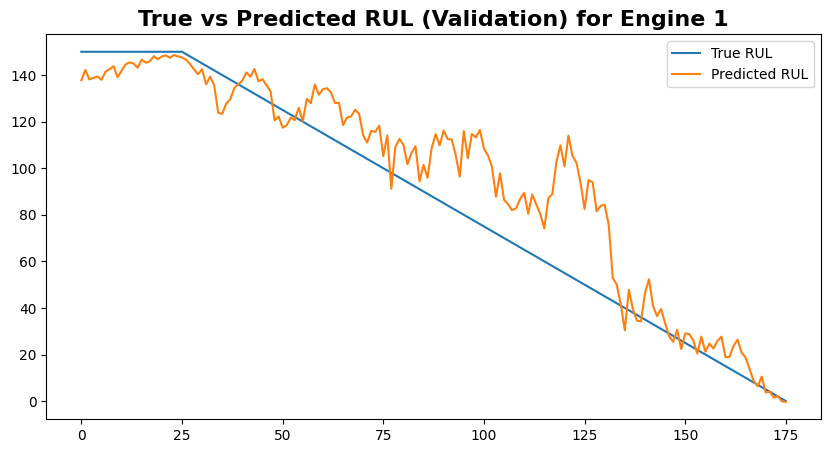

In [41]:
# True VS Predicted Plot
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:176], label='True RUL')
plt.plot(y_val_pred[:176], label='Predicted RUL')
plt.legend()
plt.title('True vs Predicted RUL (Validation) for Engine 1', fontsize=16, fontweight='bold')
plt.savefig('../reports/plots/true_vs_predicted_xgb.png')
plt.show()

The model captures the overall degradation trajectory of the engine reasonably well and successfully follows the long-term downward trend of the Remaining Useful Life (RUL). In particular, prediction accuracy improves noticeably in the critical low-RUL region close to failure, which is especially important for predictive maintenance applications where late-stage degradation detection is most relevant.

At the same time, the prediction curve still exhibits noticeable short-term fluctuations during intermediate degradation phases. This suggests that the model remains somewhat sensitive to local sensor noise and smaller variations in the engineered rolling and slope-based features.

Nevertheless, the predicted trajectory consistently follows the global degradation behavior of the engine and does not lose the overall temporal structure of the failure process.

Overall, the results indicate that the temporal feature engineering pipeline successfully extracts meaningful degradation-related information from the sensor data and already provides a strong foundation for further model optimization and comparison.